In [1]:
from sklearn.metrics import precision_score, recall_score
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [2]:
X_train = np.load('preprocessing/X_train.npy')
X_val = np.load('preprocessing/X_val.npy')
X_test = np.load('preprocessing/X_test.npy')
y_train = np.load('preprocessing/y_train.npy')
y_val = np.load('preprocessing/y_val.npy')
y_test = np.load('preprocessing/y_test.npy')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (2099, 13), Val: (450, 13), Test: (451, 13)


MLP

In [3]:
class MLP:
    def __init__(self, layer_sizes, activation='relu', l2_lambda=0.0, learning_rate=0.01,
                 momentum=0.9, weight_init='random'):
        self.layer_sizes = layer_sizes
        self.n_layers = len(layer_sizes)
        self.activation = activation
        self.l2_lambda = l2_lambda
        self.lr = learning_rate  #اندازه گامی که در هر به‌روزرسانی وزن برداشته میشود
        self.momentum = momentum  #به جای استفاده فقط از گرادیان جاری از میانگین گرادیان‌های قبلی نیز استفاده می‌شود
        self.weight_init = weight_init  #روش مقدار دهی اولیه وزن ها

        self.weights = []
        self.biases = []
        self.velocities_w = []  #سرعت‌های متناظر با وزن‌ها
        self.velocities_b = []

        for i in range(self.n_layers - 1):
            input_neurons = layer_sizes[i]
            output_neurons = layer_sizes[i + 1]

            if weight_init == 'random':  # توزیع نرمال (میانگین 0، واریانس 1، انحراف معیار 0.01) تولید می‌کند
                W = np.random.randn(input_neurons, output_neurons) * 0.01
            elif weight_init == 'xavier':  #توزیع یکنواخت در بازه [-limit, limit]
                limit = np.sqrt(6 / (input_neurons + output_neurons))
                W = np.random.uniform(-limit, limit, (input_neurons, output_neurons))
            elif weight_init == 'he':  #توزیع نرمال با میانگین 0 و انحراف معیار sqrt(2/input_neurons)
                std = np.sqrt(2 / input_neurons)
                W = np.random.normal(0, std, (input_neurons, output_neurons))

            b = np.zeros((1, output_neurons))
            self.weights.append(W)
            self.biases.append(b)
            self.velocities_w.append(np.zeros_like(W))
            self.velocities_b.append(np.zeros_like(b))

    def _activation(self, Z, derivative=False):
        if self.activation == 'relu':
            if derivative:
                return (Z > 0).astype(float)  #if Z>0 -> 1, else ->0
            return np.maximum(0, Z)  #if Z>0 -> Z, else ->0
        elif self.activation == 'tanh':  # hyperbolic tangent
            if derivative:
                return 1 - np.tanh(Z) ** 2
            return np.tanh(Z)
        elif self.activation == 'sigmoid':
            sig = 1 / (1 + np.exp(-np.clip(Z, -500, 500)))
            if derivative:
                return sig * (1 - sig)
            return sig

    def softmax(self, Z):
        Z_shift = Z - np.max(Z, axis=1, keepdims=True)
        expZ = np.exp(Z_shift)
        return expZ / np.sum(expZ, axis=1, keepdims=True)

    def forward(self, X):  #انتشار داده از لایه ورودی به لایه خروجی
        results = []
        prev_neuron = X  #(batch_size, input_neurons_size)
        for i in range(self.n_layers - 2):
            W = self.weights[i]  #(input_neurons_size, output_neurons_size)
            b = self.biases[i]  #(1, output_neurons_size)
            Z = np.dot(prev_neuron, W) + b  #(batch_size, output_neurons_size)
            A = self._activation(Z)
            results.append((prev_neuron, W, b, Z, A))
            prev_neuron = A
        W_out = self.weights[-1]
        b_out = self.biases[-1]
        Z_out = np.dot(prev_neuron, W_out) + b_out
        A_out = self.softmax(Z_out)
        results.append((prev_neuron, W_out, b_out, Z_out, A_out))
        return A_out, results

    def compute_loss(self, y_pred, y_true):
        N = y_true.shape[0]
        log_likelihood = -np.log(y_pred[np.arange(N), y_true] + 1e-8)  # جلوگیری از لگاریتم 0
        ce = np.mean(log_likelihood)
        l2 = 0  #از بیش‌برازش جلوگیری می‌کند
        if self.l2_lambda > 0:
            for W in self.weights:
                l2 += np.sum(W ** 2)
            l2 = (self.l2_lambda / (2 * N)) * l2
        return ce + l2

    def update_weights(self, dW, db):  #بخشی از سرعت قبلی + در جهت منفی گرادیان
        for i in range(len(self.weights)):
            self.velocities_w[i] = self.momentum * self.velocities_w[i] - self.lr * dW[i]
            self.weights[i] += self.velocities_w[i]
            self.velocities_b[i] = self.momentum * self.velocities_b[i] - self.lr * db[i]
            self.biases[i] += self.velocities_b[i]

    def backward(self, X_batch, y_batch, result_forward):
        N = X_batch.shape[0]
        dW = [np.zeros_like(W) for W in self.weights]
        db = [np.zeros_like(b) for b in self.biases]

        A_prev_out, W_out, b_out, Z_out, A_out = result_forward[-1]
        y_onehot = np.zeros_like(A_out)
        y_onehot[np.arange(N), y_batch] = 1
        dZ_out = A_out - y_onehot
        dW[-1] = np.dot(A_prev_out.T, dZ_out) / N
        db[-1] = np.sum(dZ_out, axis=0, keepdims=True) / N
        if self.l2_lambda > 0:
            dW[-1] += (self.l2_lambda / N) * W_out

        dA_prev = np.dot(dZ_out, W_out.T)
        for i in range(self.n_layers - 3, -1, -1):
            A_prev, W, b, Z, A = result_forward[i]
            dZ = dA_prev * self._activation(Z, derivative=True)
            dW[i] = np.dot(A_prev.T, dZ) / N
            db[i] = np.sum(dZ, axis=0, keepdims=True) / N
            if self.l2_lambda > 0:
                dW[i] += (self.l2_lambda / N) * W
            dA_prev = np.dot(dZ, W.T)

        return dW, db

    def train(self, X_train, y_train, X_val, y_val, epochs=200, batch_size=32,
              early_stopping_patience=10, verbose=True):
        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
                   'train_f1': [], 'val_f1': []}
        best_val_loss = np.inf  #بینهایت
        count = 0  # شمارنده عدم بهبود برای early stopping
        best_weights = None
        best_biases = None

        n_samples = X_train.shape[0]

        for epoch in range(epochs):
            idx = np.random.permutation(n_samples)  #ترتیب تصادفی جدید برای ایندکس‌های نمونه‌ها
            X_shuffled = X_train[idx]
            y_shuffled = y_train[idx]

            epoch_loss = 0
            n_batches = 0
            for i in range(0, n_samples, batch_size):  #از ۰ تا n_samples با گام batch_size
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]
                y_pred, result = self.forward(X_batch)
                loss = self.compute_loss(y_pred, y_batch)
                epoch_loss += loss
                n_batches += 1
                dW, db = self.backward(X_batch, y_batch, result)
                self.update_weights(dW, db)

            avg_train_loss = epoch_loss / n_batches

            y_val_pred, _ = self.forward(X_val)
            val_loss = self.compute_loss(y_val_pred, y_val)

            y_train_pred, _ = self.forward(X_train)
            train_acc = accuracy_score(y_train, np.argmax(y_train_pred, axis=1))
            train_f1 = f1_score(y_train, np.argmax(y_train_pred, axis=1), average='macro')
            val_acc = accuracy_score(y_val, np.argmax(y_val_pred, axis=1))
            val_f1 = f1_score(y_val, np.argmax(y_val_pred, axis=1), average='macro')

            history['train_loss'].append(avg_train_loss)
            history['val_loss'].append(val_loss)
            history['train_acc'].append(train_acc)
            history['val_acc'].append(val_acc)
            history['train_f1'].append(train_f1)
            history['val_f1'].append(val_f1)

            if verbose and (epoch + 1) % 10 == 0:
                print(
                    f"Epoch {epoch + 1}/{epochs} - loss: {avg_train_loss:.4f} - val_loss: {val_loss:.4f} - val_f1: {val_f1:.4f}")

            # Early stopping جلوگیری از بیش‌برازش
            if early_stopping_patience is not None and early_stopping_patience > 0:
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    count = 0
                    best_weights = [w.copy() for w in self.weights]
                    best_biases = [b.copy() for b in self.biases]
                else:
                    count += 1
                    if count >= early_stopping_patience:
                        print(f"Early stopping at epoch {epoch + 1}")
                        break
            else:
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_weights = [w.copy() for w in self.weights]
                    best_biases = [b.copy() for b in self.biases]

        if best_weights is not None:
            self.weights = best_weights
            self.biases = best_biases

        return history

    def predict(self, X):  #0و1و2
        probs, _ = self.forward(X)
        return np.argmax(probs, axis=1), probs

    def evaluate(self, X, y):
        y_pred, _ = self.predict(X)
        acc = accuracy_score(y, y_pred)
        per_class_precision = precision_score(y, y_pred, average=None)
        per_class_recall = recall_score(y, y_pred, average=None)
        macro_f1 = f1_score(y, y_pred, average='macro')
        weighted_f1 = f1_score(y, y_pred, average='weighted')
        per_class_f1 = f1_score(y, y_pred, average=None)
        cm = confusion_matrix(y, y_pred)
        return {
            'accuracy': acc,
            'macro_f1': macro_f1,
            'weighted_f1': weighted_f1,
            'per_class_f1': per_class_f1,
            'per_class_precision': per_class_precision,
            'per_class_recall': per_class_recall,
            'confusion_matrix': cm
        }

execute MLP



----------------------------------------------------------------------
آزمایش 1: [13, 32, 16, 3], act=relu, lr=0.01, init=he, l2=0.001, batch=32, epochs=150, early_stop=10
----------------------------------------------------------------------
Epoch 10/150 - loss: 0.3231 - val_loss: 0.3866 - val_f1: 0.8387
Epoch 20/150 - loss: 0.2472 - val_loss: 0.3602 - val_f1: 0.8557
Epoch 30/150 - loss: 0.2224 - val_loss: 0.3826 - val_f1: 0.8692
Early stopping at epoch 30
Training Time: 438.62 ms

Validation Macro-F1: 0.8557

----------------------------------------------------------------------
آزمایش 2: [13, 32, 16, 3], act=relu, lr=0.005, init=he, l2=0.0, batch=32, epochs=150, early_stop=10
----------------------------------------------------------------------
Epoch 10/150 - loss: 0.3801 - val_loss: 0.4329 - val_f1: 0.8352
Epoch 20/150 - loss: 0.2778 - val_loss: 0.3889 - val_f1: 0.8351
Epoch 30/150 - loss: 0.2339 - val_loss: 0.3634 - val_f1: 0.8515
Epoch 40/150 - loss: 0.2131 - val_loss: 0.3618 -

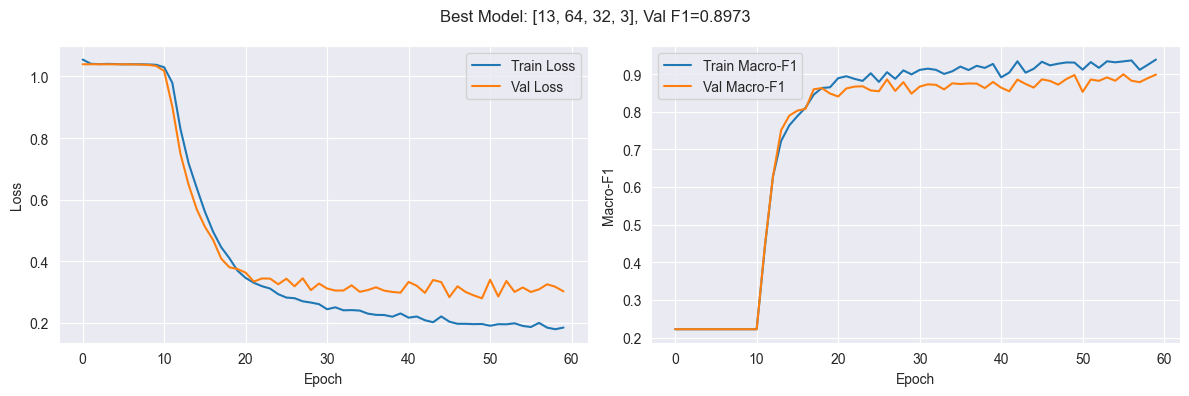

In [4]:
X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

tests = [
    {'layers': [X_train.shape[1], 32, 16, 3], 'activation': 'relu', 'lr': 0.01,
     'weight_init': 'he', 'l2': 0.001, 'batch': 32, 'epochs': 150, 'early_stop': 10},
    {'layers': [X_train.shape[1], 32, 16, 3], 'activation': 'relu', 'lr': 0.005,
     'weight_init': 'he', 'l2': 0.0, 'batch': 32, 'epochs': 150, 'early_stop': 10},
    {'layers': [X_train.shape[1], 32, 16, 3], 'activation': 'tanh', 'lr': 0.01,
     'weight_init': 'xavier', 'l2': 0.001, 'batch': 32, 'epochs': 150, 'early_stop': 10},
    {'layers': [X_train.shape[1], 128, 64, 3], 'activation': 'relu', 'lr': 0.01,
     'weight_init': 'he', 'l2': 0.001, 'batch': 64, 'epochs': 200, 'early_stop': 15},
    {'layers': [X_train.shape[1], 128, 64, 3], 'activation': 'relu', 'lr': 0.005,
     'weight_init': 'he', 'l2': 0.0, 'batch': 32, 'epochs': 200, 'early_stop': None},
    {'layers': [X_train.shape[1], 256, 128, 64, 3], 'activation': 'relu', 'lr': 0.005,
     'weight_init': 'he', 'l2': 0.001, 'batch': 64, 'epochs': 200, 'early_stop': 15},
    {'layers': [X_train.shape[1], 64, 32, 3], 'activation': 'relu', 'lr': 0.01,
     'weight_init': 'random', 'l2': 0.0, 'batch': 32, 'epochs': 150, 'early_stop': 10}]

best_model = None
best_val_f1 = -np.inf
results = []

for idx, t in enumerate(tests):
    print(f"\n{'-' * 70}")
    print(f"آزمایش {idx + 1}: {t['layers']}, act={t['activation']}, lr={t['lr']}, "
          f"init={t['weight_init']}, l2={t['l2']}, batch={t['batch']}, "
          f"epochs={t['epochs']}, early_stop={t['early_stop']}")
    print('-' * 70)

    mlp = MLP(layer_sizes=t['layers'],
              activation=t['activation'],
              l2_lambda=t['l2'],
              learning_rate=t['lr'],
              momentum=0.9,
              weight_init=t['weight_init'])

    start_time = time.perf_counter()
    history = mlp.train(X_train, y_train, X_val, y_val,
                        epochs=t['epochs'],
                        batch_size=t['batch'],
                        early_stopping_patience=t['early_stop'],
                        verbose=True)
    end_time = time.perf_counter()
    train_time_ms = (end_time - start_time) * 1000
    print(f"Training Time: {train_time_ms:.2f} ms")

    val_metrics = mlp.evaluate(X_val, y_val)
    print(f"\nValidation Macro-F1: {val_metrics['macro_f1']:.4f}")

    results.append({
        'test': t,
        'val_macro_f1': val_metrics['macro_f1'],
        'model': mlp,
        'history': history
    })

    if val_metrics['macro_f1'] > best_val_f1:
        best_val_f1 = val_metrics['macro_f1']
        best_model = mlp

# نمایش خلاصه نتایج
print("\n\n" + "=" * 70)
print("خلاصه نتایج آزمایش‌ها:")
print("=" * 70)
for i, res in enumerate(results):
    print(f"{i + 1}. {res['test']['layers']} | act={res['test']['activation']} | "
          f"lr={res['test']['lr']} | init={res['test']['weight_init']} | "
          f"l2={res['test']['l2']} | batch={res['test']['batch']} | "
          f"early_stop={res['test']['early_stop']} => Val F1={res['val_macro_f1']:.4f}")

print(f"\n بهترین Validation Macro-F1: {best_val_f1:.4f}")

# ارزیابی نهایی روی مجموعه آزمون با بهترین مدل
test_metrics = best_model.evaluate(X_test, y_test)
print("\n نتایج نهایی روی مجموعه آزمون (بهترین مدل):")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Precision per class: {test_metrics['per_class_precision']}")
print(f"Recall per class: {test_metrics['per_class_recall']}")
print(f"Macro-F1: {test_metrics['macro_f1']:.4f}")
print(f"Weighted-F1: {test_metrics['weighted_f1']:.4f}")
print(f"F1 per class: {test_metrics['per_class_f1']}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])

# رسم نمودارهای آموزش بهترین مدل
best_idx = np.argmax([r['val_macro_f1'] for r in results])
hist = results[best_idx]['history']
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist['train_loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist['train_f1'], label='Train Macro-F1')
plt.plot(hist['val_f1'], label='Val Macro-F1')
plt.xlabel('Epoch')
plt.ylabel('Macro-F1')
plt.legend()
plt.suptitle(f"Best Model: {results[best_idx]['test']['layers']}, "
             f"Val F1={results[best_idx]['val_macro_f1']:.4f}")
plt.tight_layout()
plt.show()